In [3]:
import os
import numpy as np
import polars as pl
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt

In [14]:
start_year = 2004
end_year = 2009
pred_file = f'../results/{start_year}-{end_year}/hdpsm_nrep10_mratio5_maxsamp50000_drug_reaction_associations.csv'

In [15]:
preds = pd.read_csv(pred_file)
preds['reaction'] = preds['reaction'].str.lower()
preds['mean'] = preds['a']/(preds['a']+preds['b'])
preds['prr_diff'] = np.log(preds['PRR'])-np.log(preds['uncorrected_PRR'])
preds = preds[preds['patient_sex']=='All']
preds = preds.dropna()
preds.head()

,drug,reaction,patient_sex,replicate,a,b,c,d,OR,PRR,PHI,uncorrected_a,uncorrected_b,uncorrected_c,uncorrected_d,uncorrected_OR,uncorrected_PRR,uncorrected_PHI,mean,prr_diff
0,anidulafungin,respiratory failure,All,0,5,31,5,174,5.612903,4.972222,0.196721,6.0,56.0,9757.0,1587709.0,17.434834,15.844366,0.007247,0.138889,-1.158947
1,anidulafungin,respiratory failure,All,1,5,31,4,175,7.056452,6.215278,0.217274,6.0,56.0,9757.0,1587709.0,17.434834,15.844366,0.007247,0.138889,-0.935804
2,anidulafungin,respiratory failure,All,2,5,31,7,171,3.940092,3.531746,0.161880,6.0,56.0,9757.0,1587709.0,17.434834,15.844366,0.007247,0.138889,-1.501022
3,anidulafungin,respiratory failure,All,3,5,31,1,174,28.064516,24.305556,0.301397,6.0,56.0,9757.0,1587709.0,17.434834,15.844366,0.007247,0.138889,0.427891
4,anidulafungin,respiratory failure,All,4,5,31,2,177,14.274194,12.430556,0.268684,6.0,56.0,9757.0,1587709.0,17.434834,15.844366,0.007247,0.138889,-0.242656


In [16]:
# negative controls
negative_files = [f for f in os.listdir(f'../results/{start_year}-{end_year}') if f.endswith(f"confounded_examples.csv")]
negative_df = None
for fn in negative_files:
    df = pd.read_csv(os.path.join('../', 'results', f'{start_year}-{end_year}', fn))
    if negative_df is None:
        negative_df = df
    else:
        negative_df = pd.concat([negative_df, df])

negative_df['reaction'] = negative_df['reaction'].str.lower()
negative_df['label'] = 0
negative_df.head()

,indication,reaction,drug,PHI_conf_drug,PRR_drug_rea,conf_drug,sex,age,label
0,Respiratory syncytial virus infection,respiratory syncytial virus infection,acyclovir,0.002712,7.533353,NaN,NaN,NaN,0
1,Respiratory syncytial virus infection,respiratory syncytial virus infection,budesonide,0.003810,10.647726,NaN,NaN,NaN,0
2,Respiratory syncytial virus infection,bronchiolitis,palivizumab,0.412044,1650.161718,NaN,NaN,NaN,0
3,Respiratory syncytial virus infection,cyanosis,palivizumab,0.412044,15.059840,NaN,NaN,NaN,0
4,Respiratory syncytial virus infection,respiratory syncytial virus infection,palivizumab,0.412044,1397.315362,NaN,NaN,NaN,0


In [17]:
# positive controls
fn = '../data/onsides_public_warnings_and_precautions.csv'
positive_df = pd.read_csv(fn)
positive_df['pt_meddra_term'] = positive_df['pt_meddra_term'].str.lower()
positive_df.rename(columns={'pt_meddra_term': 'reaction', 'ingredients_names': 'drug'}, inplace=True)
positive_df['label'] = 1
positive_df.head()
# fn = '../data/onsides_v3_0_0_high_confidence_mapped.csv'
# positive_df = pd.read_csv(fn)
# positive_df['meddra_name'] = positive_df['meddra_name'].str.lower()
# positive_df.rename(columns={'meddra_name': 'reaction', 'rxnorm_name': 'drug'}, inplace=True)
# positive_df['label'] = 1
# positive_df.head()

,ingredients_rxcuis,drug,pt_meddra_id,reaction,label
0,321988,escitalopram,10012218,delirium,1
1,1364347,ponatinib,10003668,atrial tachycardia,1
2,4493,fluoxetine,10025197,lymphadenopathy,1
3,4099,"estrogens, conjugated (USP)",10016807,fluid retention,1
4,753340,sapropterin,10037211,psychomotor hyperactivity,1


In [18]:
reference = pd.concat([positive_df[['drug', 'reaction', 'label']], negative_df[['drug', 'reaction', 'label']]])
reference.tail()

,drug,reaction,label
578,zidovudine,ophthalmoplegia,0
579,zidovudine,retroviral infection,0
580,zidovudine,schistosomiasis,0
581,zidovudine,stillbirth,0
582,zidovudine,tuberculoid leprosy,0


In [19]:
pred_drugs = set(preds.drug.unique())
ref_drugs = set(reference.drug.unique())
len(pred_drugs), len(ref_drugs), len(pred_drugs&ref_drugs)

(847, 1476, 843)

In [20]:
pred_reactions = set(preds.reaction.unique())
ref_reactions = set(reference.reaction.unique())
len(pred_reactions), len(ref_reactions), len(pred_reactions&ref_reactions)

(4645, 5726, 4398)

In [21]:
rep = 1
merged = pd.merge(preds, reference, on=['drug', 'reaction'], how='inner')
merged = merged[merged['replicate']==rep]
merged.label.sum(), len(merged.label)

(7484, 1854504)

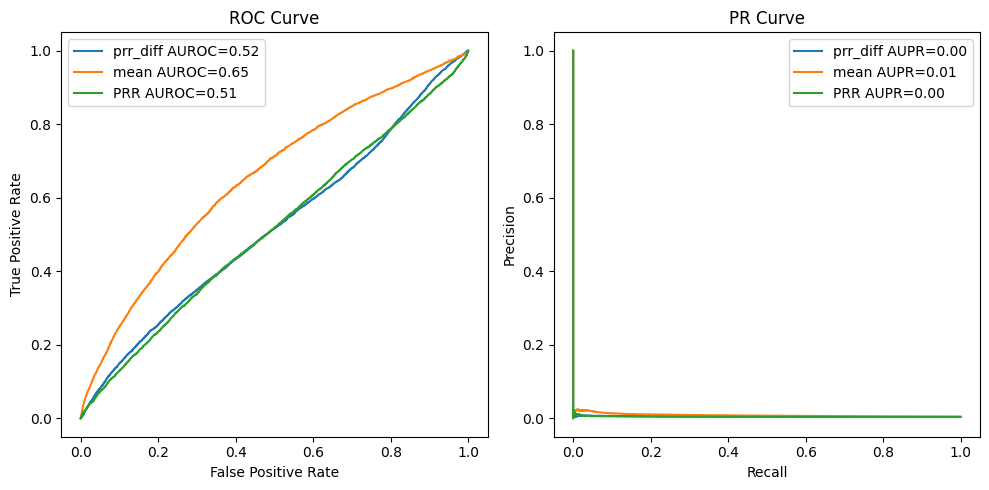

In [22]:
col = 'prr_diff'

plt.figure(figsize=(10,5))

for col in ('prr_diff', 'mean', 'PRR'):
    auroc = metrics.roc_auc_score(merged['label'], merged[col])
    aupr = metrics.average_precision_score(merged['label'], merged[col])
    fpr, tpr, thresholds = metrics.roc_curve(merged['label'], merged[col], pos_label=1)

    plt.subplot(1,2,1)
    plt.plot(fpr, tpr, label=f"{col} AUROC={auroc:.2f}")
    
    pr, re, th = metrics.precision_recall_curve(merged['label'], merged[col])
    plt.subplot(1,2,2)
    plt.plot(re, pr, label=f"{col} AUPR={aupr:.2f}")

plt.subplot(1,2,1)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.subplot(1,2,2)
plt.title('PR Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()

plt.tight_layout()
plt.savefig(f'../results/{start_year}-{end_year}/confounding_performance_roc_pr_curves.pdf')

In [23]:
neg = merged[col][merged['label']==0]
pos = merged[col][merged['label']==1]
col, neg.mean(), pos.mean()

('PRR', 2.4894341135657743, 3.1109895866724)